In [1]:
# Make the notebook wider 
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

%load_ext autoreload
%autoreload 2

<br>
<div style="text-align: left; font-family: Arial, sans-serif; color: #003366;">
    <font size=9><b>Step 1: Get Parametrical Equations</b></font>
</div>
<br>

The goal of this step is to extract the <b>parametric form</b> of the models used to predict the target variable <span style="color:#003366"><b>Die_area</b></span> based on different input features.<br><br>

Two main regression configurations are considered:

<ul>
  <li><b>Group-Wise Linear Regressor</b> — fits a separate linear model for each package type (<code>P_type</code>), revealing how the relationship between predictors and <code>Die_area</code> changes across categories.</li>
  <li><b>Classic Linear Regressor</b> — fits a single global linear model, with or without one-hot encoded categorical features such as <code>P_type</code>.</li>
</ul>

<br>

All numerical features and the target variable are expressed in <b>log₁₀ scale</b> to improve interpretability and linearity of relationships.<br><br>



In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

from Utils.bestModelEquation import print_groupwise_linear_equations
from Utils.loadData import load_data


df_train, df_test = load_data("Data/dataset.xlsx")
all_features      = ["P_area", "P_type"]  
group_models      = print_groupwise_linear_equations(df_train, all_features)


Parametric equations of Group-Wise Linear Regressor (log₁₀ scale):

Group 'BGA':
    log₁₀(Die_area) = -0.085 + 0.73·log₁₀(P_area)

Group 'QFN/DFN':
    log₁₀(Die_area) = -0.67 + 0.99·log₁₀(P_area)

Group 'QFP':
    log₁₀(Die_area) = -0.14 + 0.6·log₁₀(P_area)

Group 'SOP/SOT':
    log₁₀(Die_area) = -1.2 + 1.1·log₁₀(P_area)

Group 'WLP':
    log₁₀(Die_area) = -0.12 + 0.99·log₁₀(P_area)



In [3]:
from Utils.bestModelEquation import print_linear_equation

all_features = ["P_area", "P_type"]
_ = print_linear_equation(df_train, all_features)

log₁₀(Die_area) = -0.45 + 0.16·BGA + -0.034·QFN/DFN + -0.18·QFP + -0.38·SOP/SOT + 0.43·WLP + 0.85·log₁₀(P_area)

Note: The categorical variable 'P_type' is one-hot encoded.
      Each coefficient corresponds to the contribution of a specific package type



In [4]:
all_features = ["P_area"]
_ = print_linear_equation(df_train, all_features)

log₁₀(Die_area) = -0.46 + 0.84·log₁₀(P_area)


<br>
<div style="text-align: left; font-family: Arial, sans-serif; color: #003366;">
    <font size=9><b>Step 2: Visualize Univariate Models</b></font>
</div>
<br>

This step provides a visual representation of how each <b>univariate regressor</b> models the relationship between 
<span style="color:#003366"><b>Die_area</b></span> and a single input feature (e.g. <b>P_area</b>).  
Each model is fitted using log-transformed data, but the plots are displayed in <b>linear scale</b> for interpretability.<br><br>

For each model:
<ul>
  <li>The <b>top panel</b> shows the predicted relationship between the feature and the target on a linear scale, with <span style="color:#003366"><b>Train</b></span> and <span style="color:#003366"><b>Test</b></span> data points in blue and orange.</li>
  <li>The <b>bottom panel</b> displays the <b>log₁₀(predicted/true)</b> error as a function of <b>log₁₀(Die_area)</b>, allowing residual analysis across scales.</li>
</ul>


Using best hyperparameters from: CVRuns/features-[P_area].csv


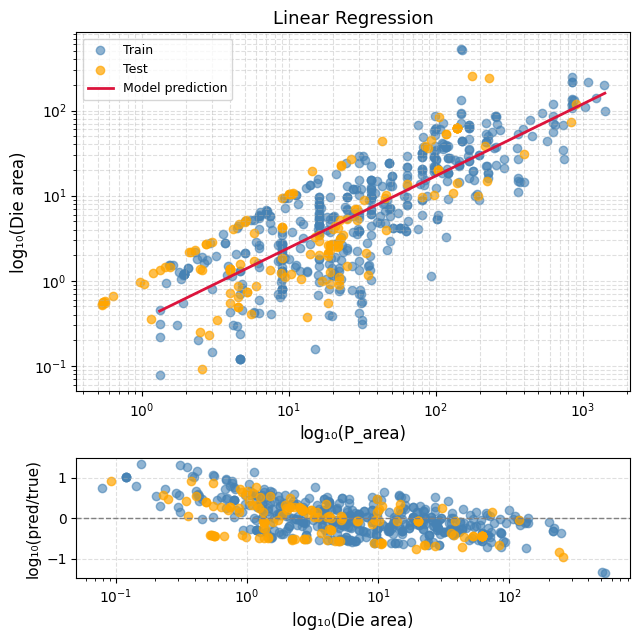

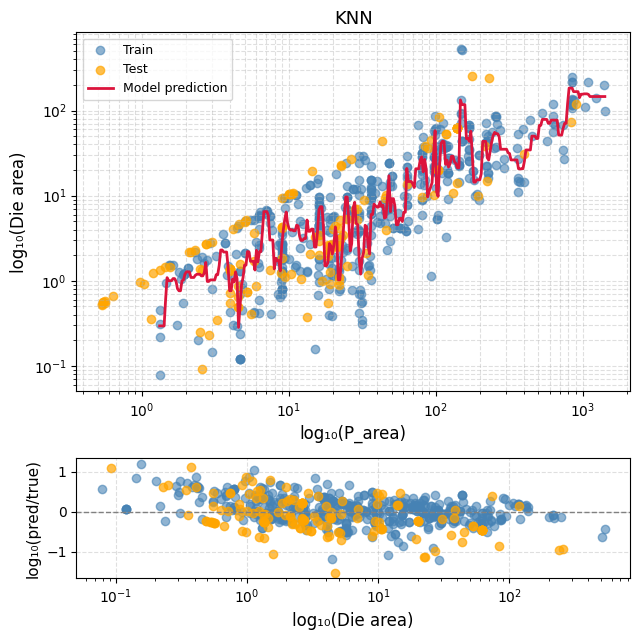

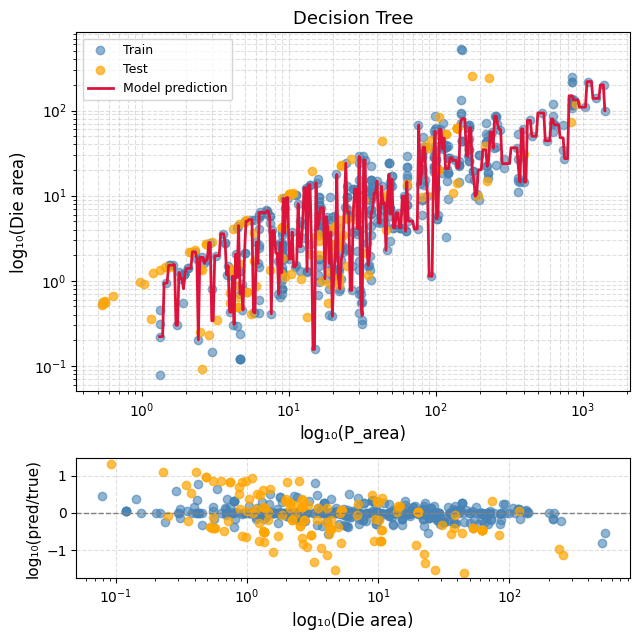

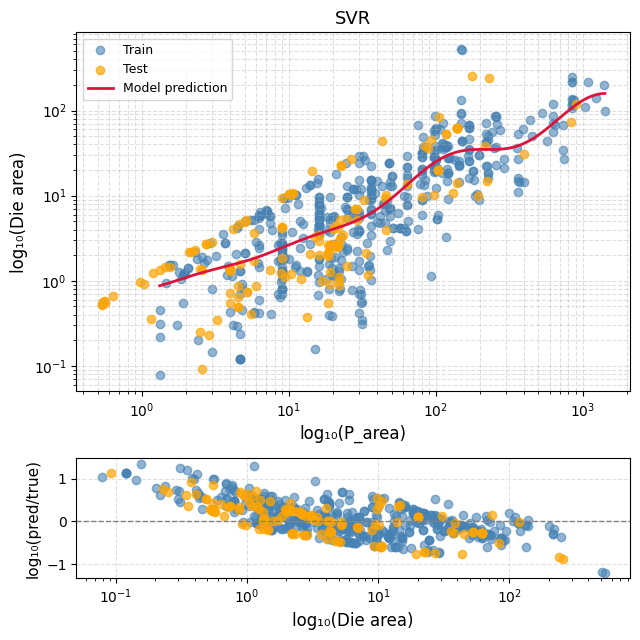

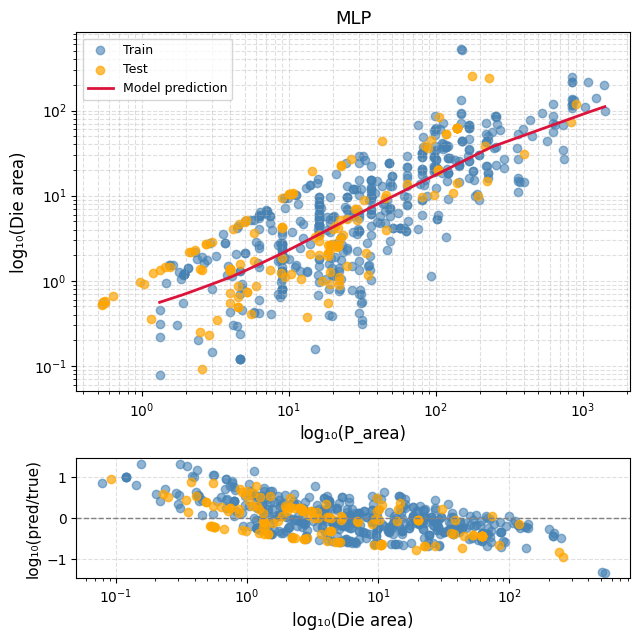

In [5]:
from MakeGraphs.plotModels import refit_and_plot_univariate  
from Utils.crossValidation import refit_models

refit_and_plot_univariate(feature="P_area")

<br>
<div style="text-align: left; font-family: Arial, sans-serif; color: #003366;">
    <font size=9><b>Step 2: Plot the Group-Wise Linear Model</b></font>
</div>
<br>

In this step, we visualize the <b>Group-Wise Linear Regressor</b> obtained previously.  
Each subplot corresponds to a specific package type (<code>P_type</code>), showing how the relationship between <span style="color:#003366"><b>Die_area</b></span> and <span style="color:#003366"><b>P_area</b></span> differs across categories.<br><br>





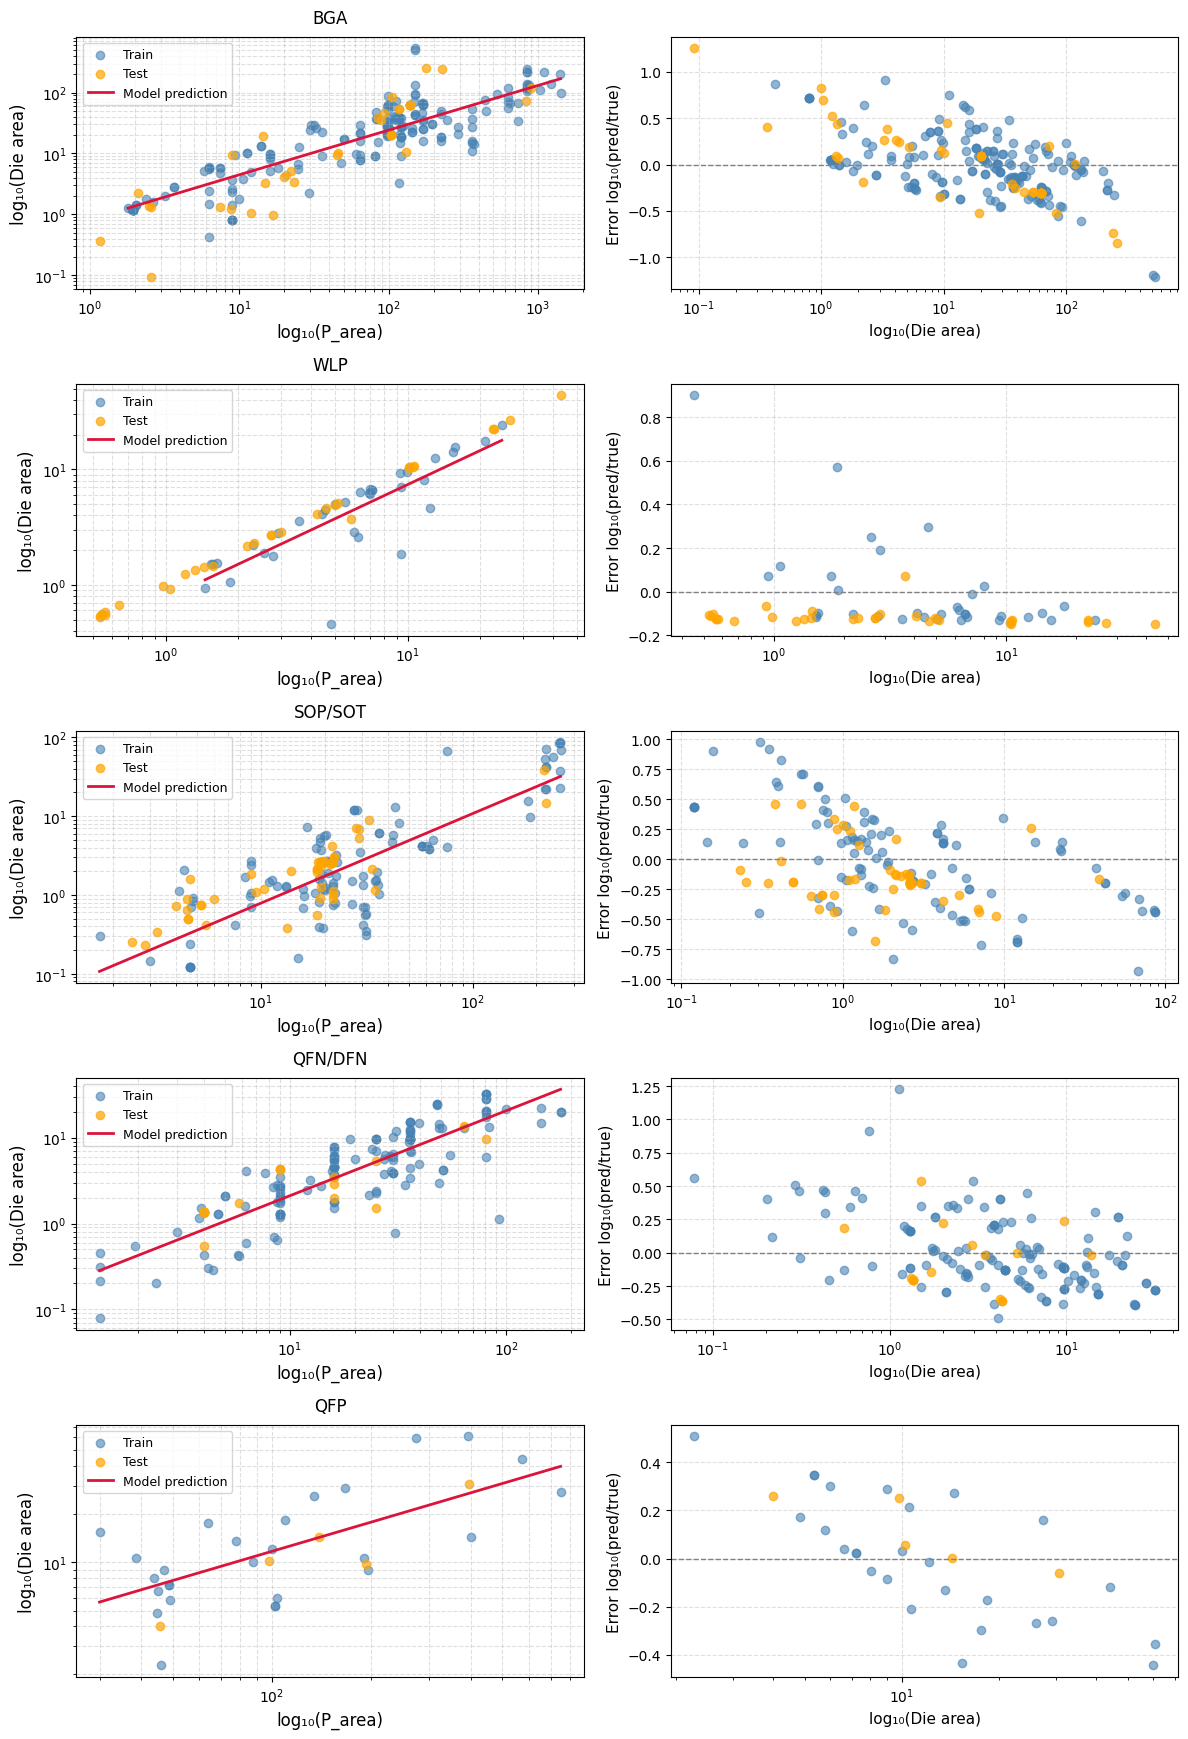

In [6]:
from MakeGraphs.plotModels import plot_groupwise_linear_models

plot_groupwise_linear_models(features=["P_area", "P_type"])